# Observables
Let $\tilde{S}_{iy}$ be the "raw" size of firm $i$ at year $y$, we then normalize it by dividing it with the average market size at that time
$$
S_{iy} = N_y \frac{\tilde{S}_{iy}}{\sum_i \tilde{S}_{iy}}
$$
where $N_y$ is the number of observation in a "year", it's always equal to $N$ is our case

then we define the growth rate as
$$
g_{iy} = \ln\left(\frac{S_{iy+1}}{S_{iy}}\right) = \ln(S_{iy+1}) - \ln(S_{iy}) =  \ln(\tilde{S}_{iy+1}) - \ln(\tilde{S}_{iy}) + \left[\ln\left(\sum_i \tilde{S}_{iy}\right) -  \ln\left(\sum_i \tilde{S}_{iy+1}\right) \right]
$$
from this the growth volatility is calculated using the adjusted mean absolute deviation
$$
\sigma_i = \sqrt{\frac{\pi}{2}} \frac{1}{T_i} \sum_y |g_{iy} - \bar{g}_i|
$$


In the paper "Firm-level production networks: what do we (really) know?" by Bacilieri et al. they describe the average degree in the network scaling as
$$
\bar{k} \sim N^{\eta}
$$
where $\eta \approx 0.13$

In [88]:
import numpy as np
import glv
from scipy.stats import truncnorm
from scipy.integrate import solve_ivp

In [89]:
# Parameters
N     = 10_000
C     = 50
sigma = 0.4
gamma = 0.0

degree_sequence = np.maximum(np.random.exponential(scale=C, size=N).astype(int), 1)
if np.sum(degree_sequence) % 2 != 0:
    degree_sequence[0] += 1

nu_pdf = lambda g: np.exp(-g)  # exponential degree distribution
mu_c   = glv.calculate_mu_c(sigma=sigma, gamma=gamma, nu_pdf=nu_pdf)["mu_c"] 
print(f"mu_c = {mu_c:.4f}")

mu_c = 0.4694


In [90]:
# Build interaction matrix at the critical point
W_sparse = glv.generate_matrix(degree_sequence, C, mu=mu_c * 1.05, sigma=sigma)

# Initial conditions for the rescaled system
x0    = np.random.uniform(0.1, 1.0, N)
M0    = x0.sum()
y0    = x0 / M0
state0 = np.concatenate((y0, [M0], [0.0]))

tau_max  = 5e5

sol = solve_ivp(
    fun=glv.rescaled_glv_sparse,
    t_span=(0, tau_max),
    y0=state0,
    args=(N, W_sparse),
    dense_output=True,
    method='RK45',
    max_step=1e2,
)
print("Integration success:", sol.success)

Integration success: True


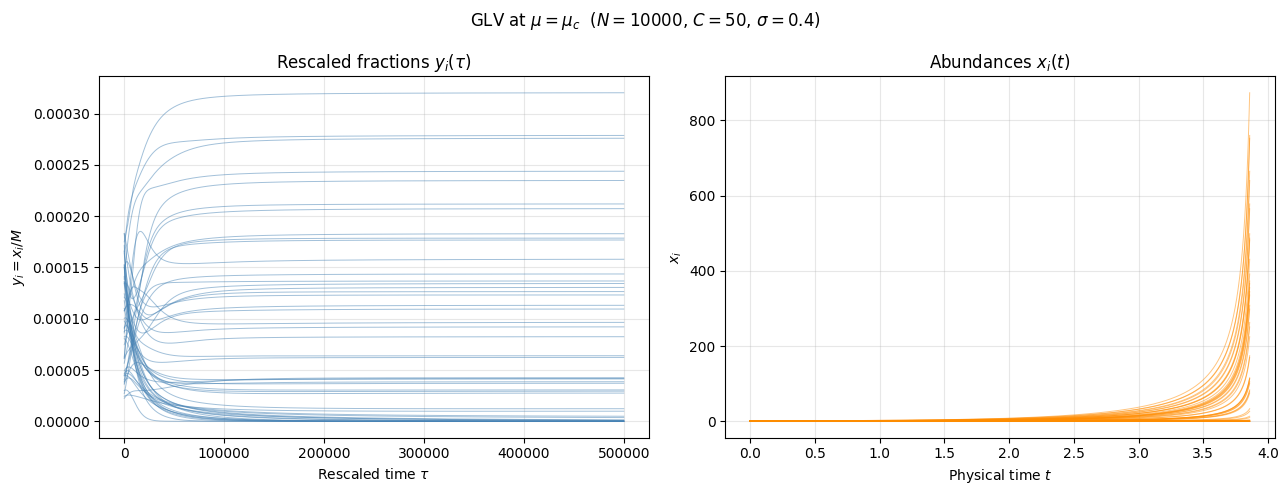

In [91]:
import matplotlib.pyplot as plt

rng_plot = np.random.default_rng(0)
sample_idx = rng_plot.choice(N, size=50, replace=False)

Y_plot = sol.y[:N, :]          # (N, n_snaps)
M_plot = sol.y[N, :]           # (n_snaps,)
t_plot = sol.y[N + 1, :]       # physical time (n_snaps,)
X_plot = Y_plot * M_plot       # x_i = y_i * M

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for i in sample_idx:
    ax1.plot(sol.t, Y_plot[i], lw=0.7, alpha=0.5, color='steelblue')
ax1.set_xlabel(r'Rescaled time $\tau$')
ax1.set_ylabel(r'$y_i = x_i / M$')
ax1.set_title('Rescaled fractions $y_i(\\tau)$')
ax1.grid(True, alpha=0.3)

for i in sample_idx:
    ax2.plot(t_plot, X_plot[i], lw=0.7, alpha=0.5, color='darkorange')
ax2.set_xlabel(r'Physical time $t$')
ax2.set_ylabel(r'$x_i$')
ax2.set_title('Abundances $x_i(t)$')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'GLV at $\\mu = \\mu_c$  ($N={N}$, $C={C}$, $\\sigma={sigma}$)')
plt.tight_layout()
plt.show()


In [92]:
# Take snapshots uniformly spaced in physical time t (not rescaled tau).
# t(tau) is monotonic since dt/dtau = 1/M > 0, so we invert it via interp.
tau_grid = sol.t
t_grid   = sol.y[N + 1, :]

n_snaps = 500
t_snaps   = np.linspace(t_grid[0], t_grid[-1], n_snaps)
tau_snaps = np.interp(t_snaps, t_grid, tau_grid)

state_snaps = sol.sol(tau_snaps)        # (N+2, n_snaps)
Y = state_snaps[:N, :]                  # relative fractions
M = state_snaps[N, :]                   # total mass

X_raw = Y * M                           # raw abundances x_i(t)

# Mask firms whose abundance ever hits the floor (extinct/clipped),
# but keep ALL firms in the normalization denominator (sum over j = M).
floor = 1e-20
alive = X_raw.min(axis=1) > floor

# Normalised size: S_iy = N * x_i / sum_j(x_j)  (sum over all firms)
S_all = N * X_raw / X_raw.sum(axis=0, keepdims=True)
S     = S_all[alive, :]

# Growth rate over uniform physical-time intervals
g     = np.diff(np.log(S), axis=1)
g_bar = g.mean(axis=1, keepdims=True)

# Adjusted MAD volatility
volatility = np.sqrt(np.pi / 2) * np.abs(g - g_bar).mean(axis=1)

size_proxy = S.mean(axis=1)

print(f"Surviving firms: {alive.sum()} / {N}")


Surviving firms: 9758 / 10000


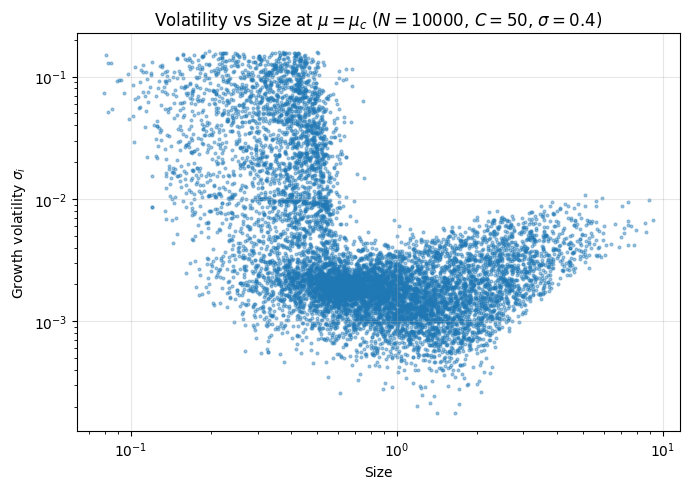

In [93]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(size_proxy, volatility, s=4, alpha=0.4)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Size')
ax.set_ylabel('Growth volatility $\\sigma_i$')
ax.set_title(f'Volatility vs Size at $\\mu = \\mu_c$ ($N={N}$, $C={C}$, $\\sigma={sigma}$)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

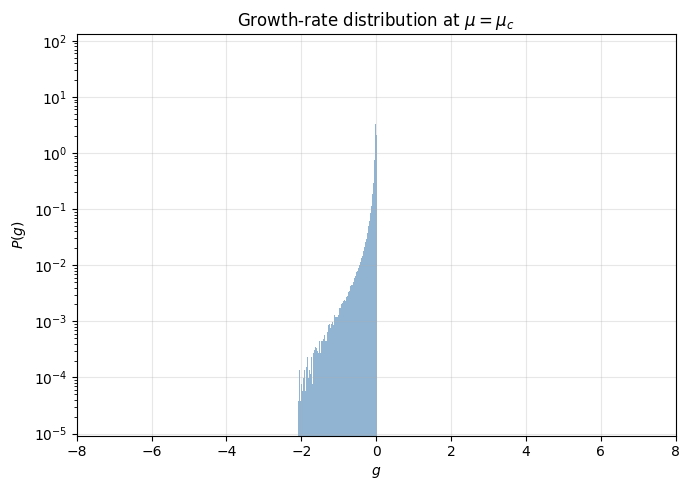

In [94]:
# Growth rate distribution P(g)
g_flat = g.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(g_flat, bins=200, density=True, alpha=0.6, color='steelblue')
ax.set_yscale('log')
ax.set_xlim(-8, 8)
ax.set_xlabel(r'$g$')
ax.set_ylabel(r'$P(g)$')
ax.set_title(f'Growth-rate distribution at $\\mu = \\mu_c$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Aggregate over many independent realizations to suppress single-run bias.
# Each realization: fresh degree sequence, fresh interaction matrix, fresh ICs.
def run_realization(N, C, sigma, mu, n_snaps, tau_max, seed):
    rng = np.random.default_rng(seed)
    np.random.seed(seed)  # generate_matrix uses np.random global state

    deg = np.maximum(rng.exponential(scale=C, size=N).astype(int), 1)
    if deg.sum() % 2 != 0:
        deg[0] += 1

    W = glv.generate_matrix(deg, C, mu=mu, sigma=sigma)

    x0 = rng.uniform(0.1, 1.0, N)
    M0 = x0.sum()
    state0 = np.concatenate((x0 / M0, [M0], [0.0]))

    sol = solve_ivp(
        fun=glv.rescaled_glv_sparse,
        t_span=(0, tau_max),
        y0=state0,
        args=(N, W),
        dense_output=True,
        method='RK45',
        max_step=1e2,
    )
    if not sol.success:
        return None

    tau_grid = sol.t
    t_grid   = sol.y[N + 1, :]
    t_snaps   = np.linspace(t_grid[0], t_grid[-1], n_snaps)
    tau_snaps = np.interp(t_snaps, t_grid, tau_grid)

    snap = sol.sol(tau_snaps)
    Y = snap[:N, :]
    M = snap[N, :]
    X_raw = Y * M

    floor = 1e-20
    alive = X_raw.min(axis=1) > floor

    S_all = N * X_raw / X_raw.sum(axis=0, keepdims=True)
    S = S_all[alive, :]

    g_r = np.diff(np.log(S), axis=1)
    g_bar = g_r.mean(axis=1, keepdims=True)
    vol_r  = np.sqrt(np.pi / 2) * np.abs(g_r - g_bar).mean(axis=1)
    size_r = S.mean(axis=1)

    return g_r.ravel(), size_r, vol_r, int(alive.sum())


n_realizations = 20
mu_run         = mu_c * 1.05
n_snaps_run    = 500
tau_max_run    = 5e5

# Running histogram so memory stays O(bins) instead of O(N * n_snaps * runs).
bin_edges  = np.linspace(-10.0, 10.0, 401)
hist_counts = np.zeros(bin_edges.size - 1, dtype=np.int64)

sizes_agg, vols_agg = [], []
n_alive_agg = 0

for r in range(n_realizations):
    out = run_realization(
        N=N, C=C, sigma=sigma, mu=mu_run,
        n_snaps=n_snaps_run, tau_max=tau_max_run,
        seed=1000 + r,
    )
    if out is None:
        print(f"  realization {r+1}: integration failed, skipping")
        continue
    g_flat_r, size_r, vol_r, n_alive = out
    c, _ = np.histogram(g_flat_r, bins=bin_edges)
    hist_counts += c
    sizes_agg.append(size_r)
    vols_agg.append(vol_r)
    n_alive_agg += n_alive
    print(f"  realization {r+1}/{n_realizations}: alive={n_alive}/{N}, |g|={g_flat_r.size}")

sizes_agg = np.concatenate(sizes_agg)
vols_agg  = np.concatenate(vols_agg)

bin_widths  = np.diff(bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
g_density   = hist_counts / (hist_counts.sum() * bin_widths)

print(f"total surviving firms across runs: {n_alive_agg}")


  realization 1/20: alive=9787/10000, |g|=4883713
  realization 2/20: alive=9742/10000, |g|=4861258
  realization 3/20: alive=9750/10000, |g|=4865250
  realization 4/20: alive=9754/10000, |g|=4867246
  realization 5/20: alive=9808/10000, |g|=4894192
  realization 6/20: alive=9728/10000, |g|=4854272
  realization 7/20: alive=9787/10000, |g|=4883713
  realization 8/20: alive=9855/10000, |g|=4917645
  realization 9/20: alive=9773/10000, |g|=4876727
  realization 10/20: alive=9764/10000, |g|=4872236
  realization 11/20: alive=9846/10000, |g|=4913154
  realization 12/20: alive=9817/10000, |g|=4898683
  realization 13/20: alive=9681/10000, |g|=4830819
  realization 14/20: alive=9823/10000, |g|=4901677
  realization 15/20: alive=9780/10000, |g|=4880220
  realization 16/20: alive=9754/10000, |g|=4867246
  realization 17/20: alive=9723/10000, |g|=4851777
  realization 18/20: alive=9661/10000, |g|=4820839
  realization 19/20: alive=9857/10000, |g|=4918643
  realization 20/20: alive=9777/10000, |

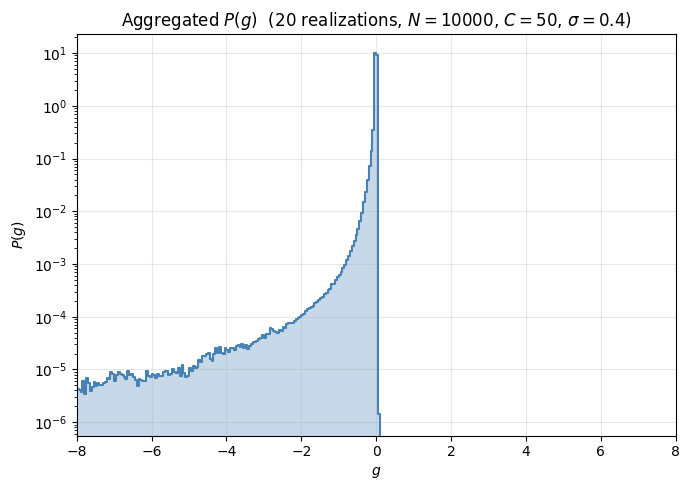

In [96]:
# Aggregated growth-rate distribution
fig, ax = plt.subplots(figsize=(7, 5))
ax.step(bin_centers, g_density, where='mid', color='steelblue')
ax.fill_between(bin_centers, g_density, step='mid', alpha=0.3, color='steelblue')
ax.set_yscale('log')
ax.set_xlim(-8, 8)
ax.set_xlabel(r'$g$')
ax.set_ylabel(r'$P(g)$')
ax.set_title(f'Aggregated $P(g)$  ({n_realizations} realizations, $N={N}$, $C={C}$, $\\sigma={sigma}$)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


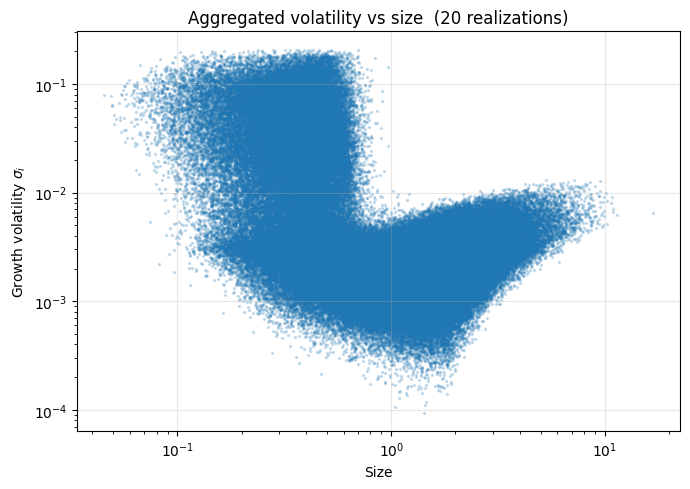

In [97]:
# Aggregated volatility vs size
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sizes_agg, vols_agg, s=2, alpha=0.2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Size')
ax.set_ylabel(r'Growth volatility $\sigma_i$')
ax.set_title(f'Aggregated volatility vs size  ({n_realizations} realizations)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


![](images/volatility_vs_size_bm.png)